In [1]:
import torch
import torch.nn as nn
import os
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

In [2]:
# IMPORTANT: MAKE SURE THIS IS WHERE YOUR TRAINING DATA IS
img_dir = './train'

In [3]:
import csv

def csv_to_dict(csv_filepath):
    result_dict = {}
    with open(csv_filepath, mode='r', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            # Ensure the row has at least 4 elements
            if len(row) >= 4:
                key = row[0]
                value = row[1:4]  # Get the next three elements
                result_dict[key] = value
    return result_dict

class GrayscaleImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_names = list(filter(lambda x: x.endswith('.jpg'), os.listdir(img_dir)))
        self.points_dict = csv_to_dict(os.path.join(self.img_dir, 'pos.csv'))
        
    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path)  # Load as PIL Image
        if self.transform:
            image = self.transform(image)
        
        target_coords = [float(coord) for coord in self.points_dict[img_name]]
        target = torch.tensor(target_coords, dtype=torch.float)
        
        return image, target


In [4]:

# Define the transform to convert images to grayscale and then to a tensor
transform = transforms.Compose([
    transforms.Grayscale(),  # Converts to grayscale
    transforms.Resize((500, 500)),  # Ensures image is 500x500
    transforms.ToTensor(),  # Converts to tensor
])

dataset = GrayscaleImageDataset(img_dir, transform=transform)
loader = DataLoader(dataset, batch_size=1, shuffle=True)


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Detector(nn.Module):
    def __init__(self):
        super(Detector, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)  # Output: 16x500x500
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)  # Output: 16x250x250
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 250 * 250, 120)  # Flatten and connect
        self.fc2 = nn.Linear(120, 3)  # Output layer for triplet

    def forward(self, x):
        residual = self.flatten(x)

        # Convolution + ReLU + Pooling
        out = self.pool(F.relu(self.conv1(x)))
        # Flatten for fully connected layer
        out = self.flatten(out)

        # Combine residual
        out = torch.cat((out, residual), dim=1)
        
        out = F.relu(self.fc1(out))
        out = self.fc2(out)
        return out


In [23]:
model = Detector()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adjust learning rate as needed

In [24]:
# This would be nice
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Detector(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1000000, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=3, bias=True)
)

In [25]:
losses = []
def train(model, loader, criterion, optimizer, num_epochs=5):
    global losses
    model.train()  # Set the model to training mode

    for epoch in tqdm(range(num_epochs)):
        running_loss = 0.0
        count = 0
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)  # Move data to the device

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            count += 1  # Increment count for each batch
            
        losses.append(running_loss / count)

In [26]:
train(model, loader, criterion, optimizer, 80)

  0%|          | 0/80 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1250000 and 1000000x120)

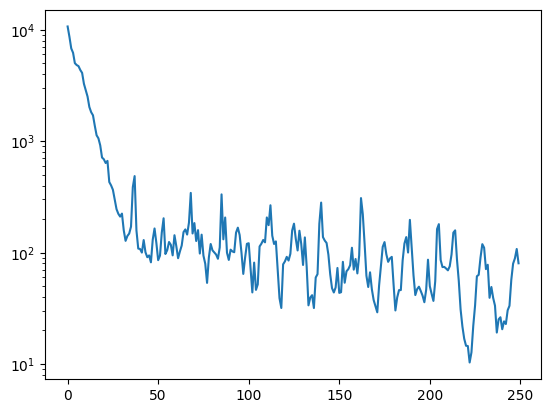

<Figure size 1000x600 with 0 Axes>

In [21]:
fig, ax = plt.subplots()
plt.figure(figsize=(10, 6))  # Set the figure size
ax.plot(losses, label='Training Loss')
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.title('Training Loss Over Time')
# plt.legend()
ax.set_yscale('log')

In [12]:
losses[-1]

80.1773195552826